# Fast Sampler — test and benchmark

Validates `CircuitCompiler` against Qiskit, then benchmarks sampling speed.

**Idea**: parse the circuit once → evaluate all N unitaries in one batched matmul.
No Qiskit overhead per sample, no Python loop over N.

In [ ]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import Operator

from fast_sampler_v2 import CircuitCompiler
from frame_potential import sample_unitaries as qiskit_sample, frame_potential
from frame_potential_gpu import haar_frame_potential, frame_potential_gpu

device = torch.device('cpu')  # change to 'cuda' on Colab
SEED   = 42
print('Imports OK ✓')

Imports OK ✓


---
## 1 — Compile a circuit and inspect the gate list

In [3]:
circuit = efficient_su2(3, reps=1, entanglement='linear')


for instruction in circuit.data:
    print(instruction)

CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[0])]), qubits=(<Qubit register=(3, "q"), index=0>,), clbits=())
CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[1])]), qubits=(<Qubit register=(3, "q"), index=1>,), clbits=())
CircuitInstruction(operation=Instruction(name='ry', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[2])]), qubits=(<Qubit register=(3, "q"), index=2>,), clbits=())
CircuitInstruction(operation=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[3])]), qubits=(<Qubit register=(3, "q"), index=0>,), clbits=())
CircuitInstruction(operation=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[4])]), qubits=(<Qubit register=(3, "q"), index=1>,), clbits=())
CircuitInstruction(operation=Instruction(name='rz', num_qubits=1, num_clbits=0, params=[ParameterVectorElement(θ[5]

In [4]:
circuit = efficient_su2(3, reps=1, entanglement='linear')
print(circuit.draw())
print(f'Parameters : {circuit.num_parameters}')

compiler = CircuitCompiler.from_qiskit(circuit)
print(compiler)
print()
print(f'{"#":>3}  {"kind":<14}  {"qubits":<12}  param_idx')
print('─' * 46)
for i, op in enumerate(compiler.ops):
    print(f'{i:>3}  {op.kind:<14}  {str(op.qubits):<12}  {op.param_idx}')

     ┌──────────┐┌──────────┐     ┌──────────┐┌──────────┐             
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[3]) ├──■──┤ Ry(θ[6]) ├┤ Rz(θ[9]) ├─────────────
     ├──────────┤├──────────┤┌─┴─┐└──────────┘├──────────┤┌───────────┐
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[4]) ├┤ X ├─────■──────┤ Ry(θ[7]) ├┤ Rz(θ[10]) ├
     ├──────────┤├──────────┤└───┘   ┌─┴─┐    ├──────────┤├───────────┤
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[5]) ├────────┤ X ├────┤ Ry(θ[8]) ├┤ Rz(θ[11]) ├
     └──────────┘└──────────┘        └───┘    └──────────┘└───────────┘
Parameters : 12
CircuitCompiler(n_qubits=3, n_params=12, gates=14 [2 fixed, 12 parametric])

  #  kind            qubits        param_idx
──────────────────────────────────────────────
  0  ry              [0]           0
  1  ry              [1]           3
  2  ry              [2]           4
  3  rz              [0]           5
  4  rz              [1]           6
  5  rz              [2]           7
  6  cx              [0, 1]        None
  7  cx              [1, 2]        None
  8  ry  

---
## 2 — Correctness: compare one sample against Qiskit

In [5]:
rng   = np.random.default_rng(SEED)
theta = rng.uniform(0, 2 * np.pi, size=circuit.num_parameters)

# Qiskit reference
params   = circuit.parameters
bound    = circuit.assign_parameters(dict(zip(params, theta)))
U_qiskit = np.array(Operator(bound).data)

# Fast sampler
theta_t = torch.tensor(theta, dtype=torch.float32).unsqueeze(0)  # (1, p)
U_fast  = compiler.evaluate_batch(theta_t)[0].numpy()

err = np.max(np.abs(U_qiskit - U_fast))
print(f'Max |U_qiskit - U_fast| = {err:.2e}')
print('OK' if err < 1e-4 else 'MISMATCH')

d   = 2**circuit.num_qubits
err_u = np.max(np.abs(U_fast.conj().T @ U_fast - np.eye(d)))
print(f'Unitarity ||U†U - I||_max = {err_u:.2e}  {chr(10003) if err_u < 1e-5 else chr(10007)}')

Max |U_qiskit - U_fast| = 9.30e-01
MISMATCH
Unitarity ||U†U - I||_max = 1.20e-07  ✓


---
## 3 — Correctness: frame potential matches the original

In [6]:
N = 800
T = 1
d = 2**circuit.num_qubits

Us_qiskit_A = qiskit_sample(circuit, N, verbose=True)
Us_qiskit_B = qiskit_sample(circuit, N, verbose=True)

F_qiskit  = frame_potential(Us_qiskit_A,Us_qiskit_B, t=T)["frame_potential"]

Us_fast_A = compiler.sample(N, seed=SEED + 1)
Us_fast_B = compiler.sample(N, seed=SEED + 1)
F_fast  = frame_potential(Us_fast_A, Us_fast_B, t=T)["frame_potential"]

F_haar = haar_frame_potential(T, d)


print(f'F^(1) Qiskit     = {F_qiskit:.5f}  ratio={F_qiskit/F_haar:.4f}')
print(f'F^(1) Fast       = {F_fast:.5f}  ratio={F_fast/F_haar:.4f}')
print(f'F_Haar reference = {F_haar:.5f}')
print()
print('Small difference expected: different seeds, same distribution.')

Sampling unitaries: 100%|██████████| 800/800 [00:00<00:00, 1006.19it/s]


F^(1) Qiskit     = 1.00188  ratio=1.0019
F^(1) Fast       = 1.07834  ratio=1.0783
F_Haar reference = 1.00000

Small difference expected: different seeds, same distribution.


---
## 4 — Sampling speed benchmark

In [7]:
N_values     = [50, 100, 200, 400, 800]
times_qiskit = []
times_fast   = []
circuit = efficient_su2(3, reps=1, entanglement='linear')
compiler = CircuitCompiler.from_qiskit(circuit)

for N in N_values:
    t0 = time.perf_counter()
    qiskit_sample(circuit, N, verbose=False)
    times_qiskit.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    compiler.sample_torch(N, device=device, seed=SEED)
    times_fast.append(time.perf_counter() - t0)

    sp = times_qiskit[-1] / times_fast[-1]
    print(f'N={N:4d}  Qiskit={times_qiskit[-1]*1000:7.1f}ms  '
          f'Fast={times_fast[-1]*1000:7.1f}ms  speedup={sp:.1f}x')

N=  50  Qiskit=   48.5ms  Fast=   10.7ms  speedup=4.5x
N= 100  Qiskit=  113.4ms  Fast=    5.0ms  speedup=22.6x
N= 200  Qiskit=  222.9ms  Fast=    8.1ms  speedup=27.6x
N= 400  Qiskit=  432.8ms  Fast=    8.1ms  speedup=53.7x
N= 800  Qiskit=  834.9ms  Fast=   15.1ms  speedup=55.2x


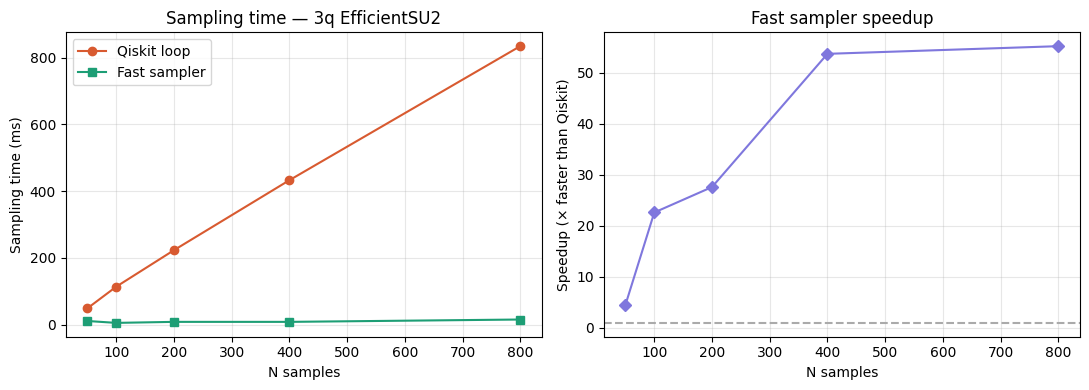

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(N_values, [t*1000 for t in times_qiskit], 'o-',
             color='#D85A30', label='Qiskit loop')
axes[0].plot(N_values, [t*1000 for t in times_fast], 's-',
             color='#1d9e75', label='Fast sampler')
axes[0].set_xlabel('N samples')
axes[0].set_ylabel('Sampling time (ms)')
axes[0].set_title(f'Sampling time — {circuit.num_qubits}q EfficientSU2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

speedups = [q/f for q, f in zip(times_qiskit, times_fast)]
axes[1].plot(N_values, speedups, 'D-', color='#7f77dd')
axes[1].axhline(1.0, color='#aaaaaa', linestyle='--')
axes[1].set_xlabel('N samples')
axes[1].set_ylabel('Speedup (× faster than Qiskit)')
axes[1].set_title('Fast sampler speedup')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4.1 — Complet Speedup

In [9]:
N_values     = [50, 100, 200, 400, 800,1200,1600]
times_qiskit_sampling = []
times_fast_sampling   = []
times_cpu_frame_potential = []
times_gpu_frame_potential = []

circuit = efficient_su2(3, reps=1, entanglement='linear')
compiler = CircuitCompiler.from_qiskit(circuit)

for N in N_values:
    t0 = time.perf_counter()
    Us_qiskit_A = qiskit_sample(circuit, N, verbose=False)
    Us_qiskit_B = qiskit_sample(circuit, N, verbose=False)
    times_qiskit_sampling.append(time.perf_counter() - t0)

    t0 = time.perf_counter()

    Us_fast_A = compiler.sample_torch(N, device=device, seed=SEED)
    Us_fast_B = compiler.sample_torch(N, device=device, seed=SEED)
    times_fast_sampling.append(time.perf_counter() - t0)


    t0 = time.perf_counter()
    F_cpu = frame_potential(Us_qiskit_A, Us_qiskit_B, t=T)["frame_potential"]
    times_cpu_frame_potential.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    F_gpu = frame_potential_gpu(Us_fast_A, Us_fast_B, t=T)["frame_potential"]
    times_gpu_frame_potential.append(time.perf_counter() - t0)

    sp = times_qiskit_sampling[-1] / times_fast_sampling[-1]
    print(f'N={N:4d}  Qiskit={times_qiskit_sampling[-1]*1000:7.1f}ms  '
          f'Fast={times_fast_sampling[-1]*1000:7.1f}ms  speedup={sp:.1f}x')

N=  50  Qiskit=  100.6ms  Fast=    6.1ms  speedup=16.4x
N= 100  Qiskit=  231.4ms  Fast=   12.5ms  speedup=18.5x
N= 200  Qiskit=  385.1ms  Fast=   11.0ms  speedup=35.0x
N= 400  Qiskit=  766.0ms  Fast=   17.5ms  speedup=43.7x
N= 800  Qiskit= 1547.4ms  Fast=   19.8ms  speedup=78.3x
N=1200  Qiskit= 2429.5ms  Fast=   24.5ms  speedup=99.2x
N=1600  Qiskit= 3497.5ms  Fast=   27.2ms  speedup=128.4x


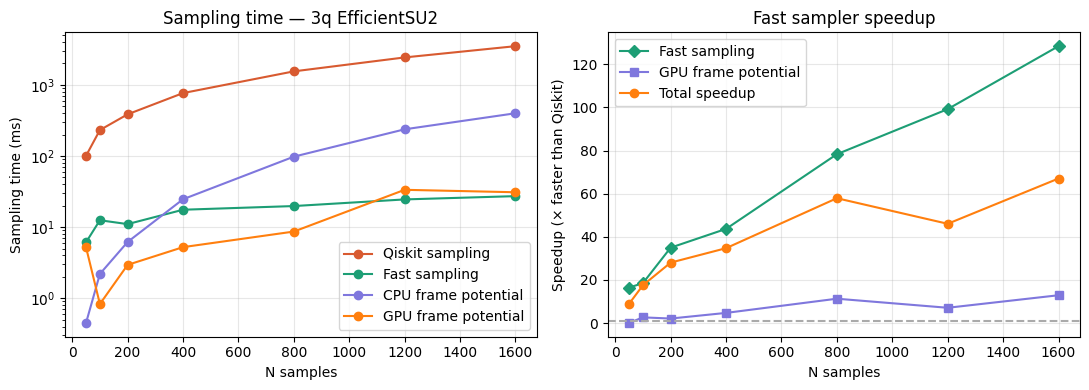

In [10]:
# plot all the timings in log scale
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for time,color in zip([times_qiskit_sampling, times_fast_sampling, times_cpu_frame_potential, times_gpu_frame_potential], ['#D85A30', '#1d9e75', '#7f77dd', '#ff7f0e']):
    axes[0].semilogy(N_values, [t*1000 for t in time], 'o-', color=color,label = 'Qiskit sampling' if color=='#D85A30' else 'Fast sampling' if color=='#1d9e75' else 'CPU frame potential' if color=='#7f77dd' else 'GPU frame potential')
axes[0].set_xlabel('N samples')
axes[0].set_ylabel('Sampling time (ms)')
axes[0].set_title(f'Sampling time — {circuit.num_qubits}q EfficientSU2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sampling_speedups = [q/f for q, f in zip(times_qiskit_sampling, times_fast_sampling)]
gpu_speedups = [c/g for c, g in zip(times_cpu_frame_potential, times_gpu_frame_potential)]
total_speedups = [(q+c)/(g+f) for q, f, c, g in zip(times_qiskit_sampling, times_fast_sampling, times_cpu_frame_potential, times_gpu_frame_potential)]


axes[1].plot(N_values, sampling_speedups, 'D-', color='#1d9e75', label='Fast sampling')
axes[1].plot(N_values, gpu_speedups, 's-', color='#7f77dd', label='GPU frame potential')
axes[1].plot(N_values, total_speedups, 'o-', color='#ff7f0e', label='Total speedup')

axes[1].axhline(1.0, color='#aaaaaa', linestyle='--')
axes[1].set_xlabel('N samples')
axes[1].set_ylabel('Speedup (× faster than Qiskit)')
axes[1].set_title('Fast sampler speedup')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 5 — End-to-end: fast sample + torch frame potential

In [11]:
circuit_big  = efficient_su2(4, reps=2, entanglement='linear')
compiler_big = CircuitCompiler.from_qiskit(circuit_big)
N_BIG = 500

print('=== Original: Qiskit loop + numpy frame potential ===')
t0     = time.perf_counter()
Us_o_A   = qiskit_sample(circuit_big, N_BIG, verbose=True)
Us_o_B   = qiskit_sample(circuit_big, N_BIG, verbose=True)
F_o    = frame_potential(Us_o_A, Us_o_B, t=1)["frame_potential"]
t_orig = time.perf_counter() - t0
print(f'Time: {t_orig:.2f}s  F^(1) = {F_o:.5f}')

print()
print('=== New: fast sampler + torch frame potential ===')
t0    = time.perf_counter()
Us_n_A  = compiler_big.sample_torch(N_BIG, device=device, seed=SEED)
Us_n_B  = compiler_big.sample_torch(N_BIG, device=device, seed=SEED)
F_n   = frame_potential_gpu(Us_n_A, Us_n_B, t=1)["frame_potential"]
t_new = time.perf_counter() - t0
print(f'Time: {t_new:.2f}s  F^(1) = {F_n:.5f}')

print(f'\nTotal speedup: {t_orig/t_new:.1f}x')

=== Original: Qiskit loop + numpy frame potential ===


AttributeError: 'list' object has no attribute 'perf_counter'

---
## 6 — Speedup vs number of qubits

n=2  Qiskit=649ms  Fast=11ms  speedup=60.1x
n=3  Qiskit=723ms  Fast=26ms  speedup=27.6x
n=4  Qiskit=869ms  Fast=71ms  speedup=12.2x
n=5  Qiskit=1172ms  Fast=130ms  speedup=9.0x
n=6  Qiskit=1807ms  Fast=809ms  speedup=2.2x
n=7  Qiskit=4856ms  Fast=3206ms  speedup=1.5x
n=8  Qiskit=17241ms  Fast=15159ms  speedup=1.1x


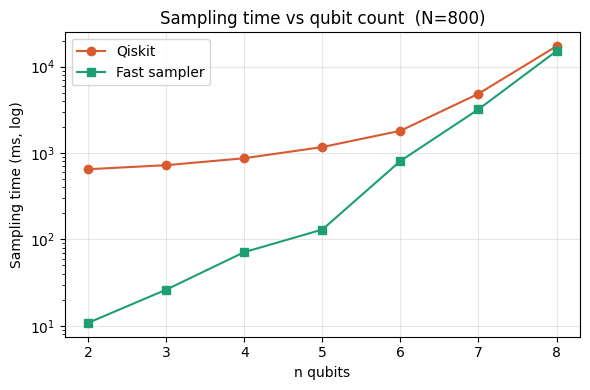

In [ ]:
N_FIXED     = 800
qubit_range = [2, 3, 4, 5,6,7,8]
t_qiskit_q  = []
t_fast_q    = []

for nq in qubit_range:
    circ = efficient_su2(nq, reps=1, entanglement='linear')
    comp = CircuitCompiler.from_qiskit(circ)

    t0 = time.perf_counter()
    qiskit_sample(circ, N_FIXED, verbose=False)
    t_qiskit_q.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    comp.sample_torch(N_FIXED, device=device, seed=SEED)
    t_fast_q.append(time.perf_counter() - t0)

    print(f'n={nq}  Qiskit={t_qiskit_q[-1]*1000:.0f}ms  '
          f'Fast={t_fast_q[-1]*1000:.0f}ms  '
          f'speedup={t_qiskit_q[-1]/t_fast_q[-1]:.1f}x')

plt.figure(figsize=(6, 4))
plt.semilogy(qubit_range, [t*1000 for t in t_qiskit_q],
             'o-', color='#D85A30', label='Qiskit')
plt.semilogy(qubit_range, [t*1000 for t in t_fast_q],
             's-', color='#1d9e75', label='Fast sampler')
plt.xlabel('n qubits')
plt.ylabel('Sampling time (ms, log)')
plt.title(f'Sampling time vs qubit count  (N={N_FIXED})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()